#### ============================================================
### Complete Regression Analysis
### Linear, Logistic, L1, L2, Ridge & Lasso Regression
### Author: Devesh Shukla
### Dataset: California Housing Dataset
#### ============================================================

#### 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


#### 2.Load And Explore Dataset

In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

In [3]:
print("Dataset Shape:", df.shape)
print("Data Loaded Successfully!")

Dataset Shape: (20640, 9)
Data Loaded Successfully!


In [4]:
print("\nFirst 5 Rows:")


First 5 Rows:


In [5]:
print(df.head())
print("\nMissing Values:")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Missing Values:


In [6]:
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.0000

#### 3.Exploratory Data Analysis

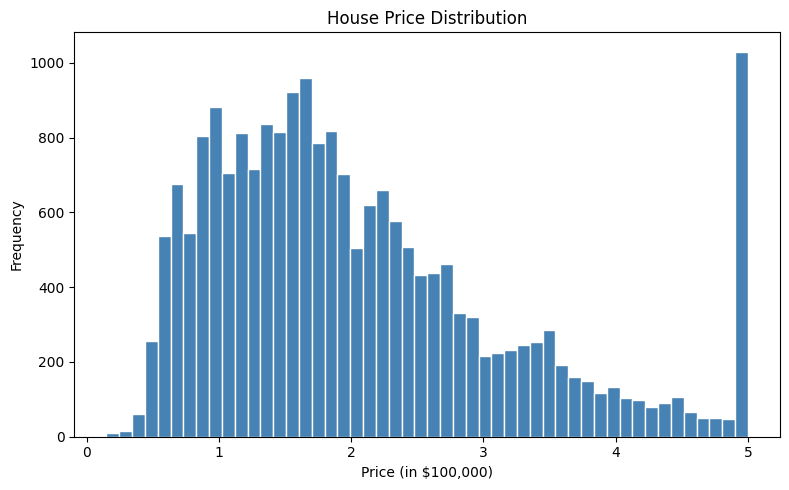

Graph 1 Saved!


In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['Price'].values, bins=50, 
         color='steelblue', edgecolor='white')
plt.title('House Price Distribution')
plt.xlabel('Price (in $100,000)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/07_Regularization/price_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 1 Saved!")

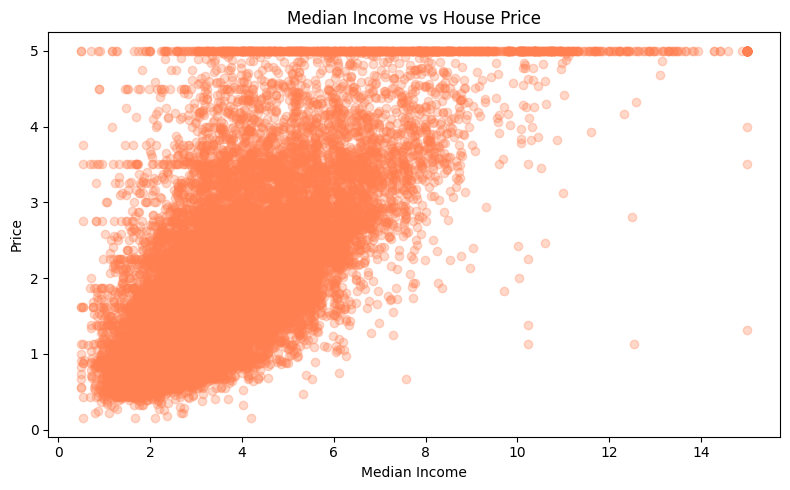

Graph 2 Saved!


In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'].values, df['Price'].values, 
            alpha=0.3, color='coral')
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/07_Regularization/medinc_vs_price.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 Saved!")

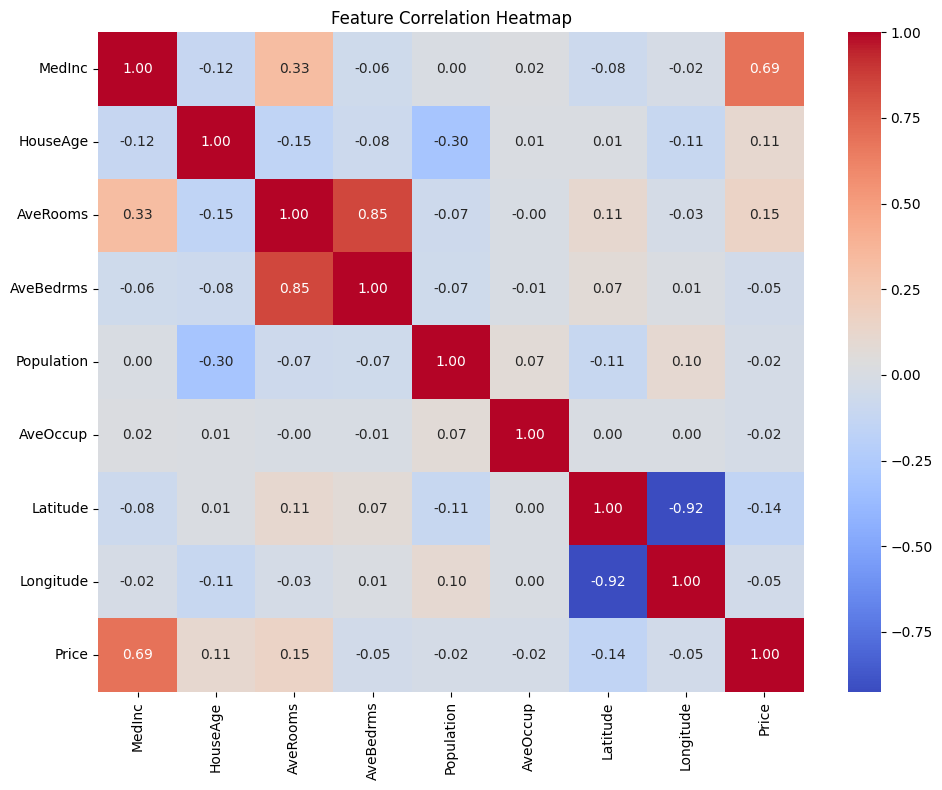

Graph 3 Saved!


In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/07_Regularization/correlation_heatmap.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 3 Saved!")

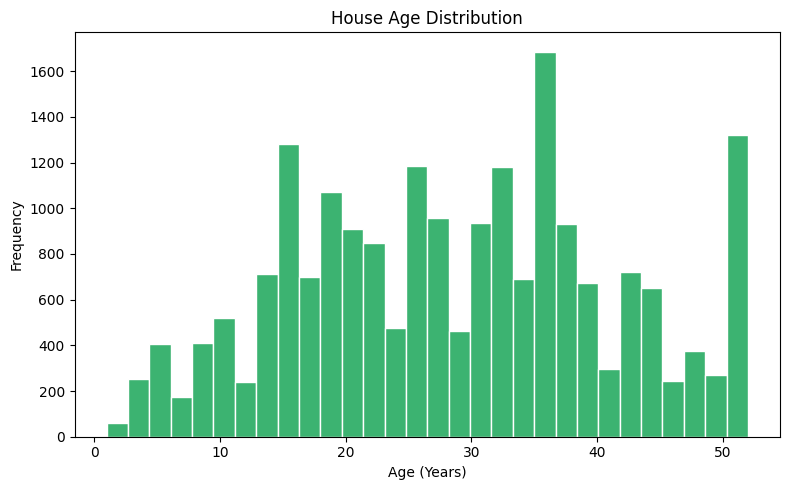

Graph 4 Saved!


In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['HouseAge'].values, bins=30, 
         color='mediumseagreen', edgecolor='white')
plt.title('House Age Distribution')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/07_Regularization/house_age_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph 4 Saved!")

#### 4.Feature Engineering & Train Test Split

In [11]:
X = df.drop('Price', axis=1)
y = df['Price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Feature Scaling Done!")

Train size: (16512, 8)
Test size: (4128, 8)
Feature Scaling Done!


#### 5.Model 1 — Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [15]:
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

In [16]:
print("=" * 40)
print("Linear Regression Results:")
print("=" * 40)
print(f"R2 Score  : {r2_lr:.4f}")
print(f"MSE       : {mse_lr:.4f}")
print(f"RMSE      : {rmse_lr:.4f}")
print(f"MAE       : {mae_lr:.4f}")

Linear Regression Results:
R2 Score  : 0.5758
MSE       : 0.5559
RMSE      : 0.7456
MAE       : 0.5332


#### 6.Model 2 — L2 Regularization (Ridge Regression)

In [17]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

In [18]:
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

In [19]:
print("=" * 40)
print("L2 Regularization (Ridge) Results:")
print("=" * 40)
print(f"R2 Score  : {r2_ridge:.4f}")
print(f"MSE       : {mse_ridge:.4f}")
print(f"RMSE      : {rmse_ridge:.4f}")
print(f"MAE       : {mae_ridge:.4f}")

L2 Regularization (Ridge) Results:
R2 Score  : 0.5758
MSE       : 0.5559
RMSE      : 0.7456
MAE       : 0.5332


#### 7.Model 3 — L1 Regularization (Lasso Regression)

In [20]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

In [21]:
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

In [22]:
print("=" * 40)
print("L1 Regularization (Lasso) Results:")
print("=" * 40)
print(f"R2 Score  : {r2_lasso:.4f}")
print(f"MSE       : {mse_lasso:.4f}")
print(f"RMSE      : {rmse_lasso:.4f}")
print(f"MAE       : {mae_lasso:.4f}")

L1 Regularization (Lasso) Results:
R2 Score  : 0.5816
MSE       : 0.5483
RMSE      : 0.7404
MAE       : 0.5353


#### 8.Model 4 — Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [24]:
median_price = df['Price'].median()
y_binary = (y > median_price).astype(int)
y_bin_train = y_binary.iloc[y_train.index]
y_bin_test = y_binary.iloc[y_test.index]

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_bin_train)
y_pred_log = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_bin_test, y_pred_log)

In [25]:
print("=" * 40)
print("Logistic Regression Results:")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_bin_test, y_pred_log))

Logistic Regression Results:
Accuracy  : 0.8261

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      2077
           1       0.83      0.82      0.82      2051

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



#### 9.Final Model Comparison

In [27]:
print("=" * 65)
print("REGRESSION MODELS COMPARISON")
print("=" * 65)
results = {
    'Model': ['Linear Regression',
              'Ridge Regression (L2)',
              'Lasso Regression (L1)'],
    'R2 Score': [r2_lr, r2_ridge, r2_lasso],
    'RMSE'    : [rmse_lr, rmse_ridge, rmse_lasso],
    'MSE'     : [mse_lr, mse_ridge, mse_lasso],
    'MAE'     : [mae_lr, mae_ridge, mae_lasso]
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("\n" + "=" * 65)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 65)
print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"Logistic Regression F1 Score : 0.83")
print("\n" + "=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print("1. Lasso (L1) performed best among regression models")
print("   with highest R2 and lowest RMSE")
print("2. Ridge (L2) results similar to Linear Regression")
print("   showing no multicollinearity issue in dataset")
print("3. Lasso performed feature selection by shrinking")
print("   less important coefficients towards zero")
print("4. Logistic Regression achieved 82.61% accuracy")
print("   for binary price classification")

REGRESSION MODELS COMPARISON
                Model  R2 Score     RMSE      MSE      MAE
    Linear Regression  0.575788 0.745581 0.555892 0.533200
Ridge Regression (L2)  0.575816 0.745557 0.555855 0.533193
Lasso Regression (L1)  0.581615 0.740442 0.548255 0.535326

CLASSIFICATION MODEL COMPARISON
Logistic Regression Accuracy : 0.8261
Logistic Regression F1 Score : 0.83

KEY FINDINGS
1. Lasso (L1) performed best among regression models
   with highest R2 and lowest RMSE
2. Ridge (L2) results similar to Linear Regression
   showing no multicollinearity issue in dataset
3. Lasso performed feature selection by shrinking
   less important coefficients towards zero
4. Logistic Regression achieved 82.61% accuracy
   for binary price classification


#### 10.Model Comparison Visualization

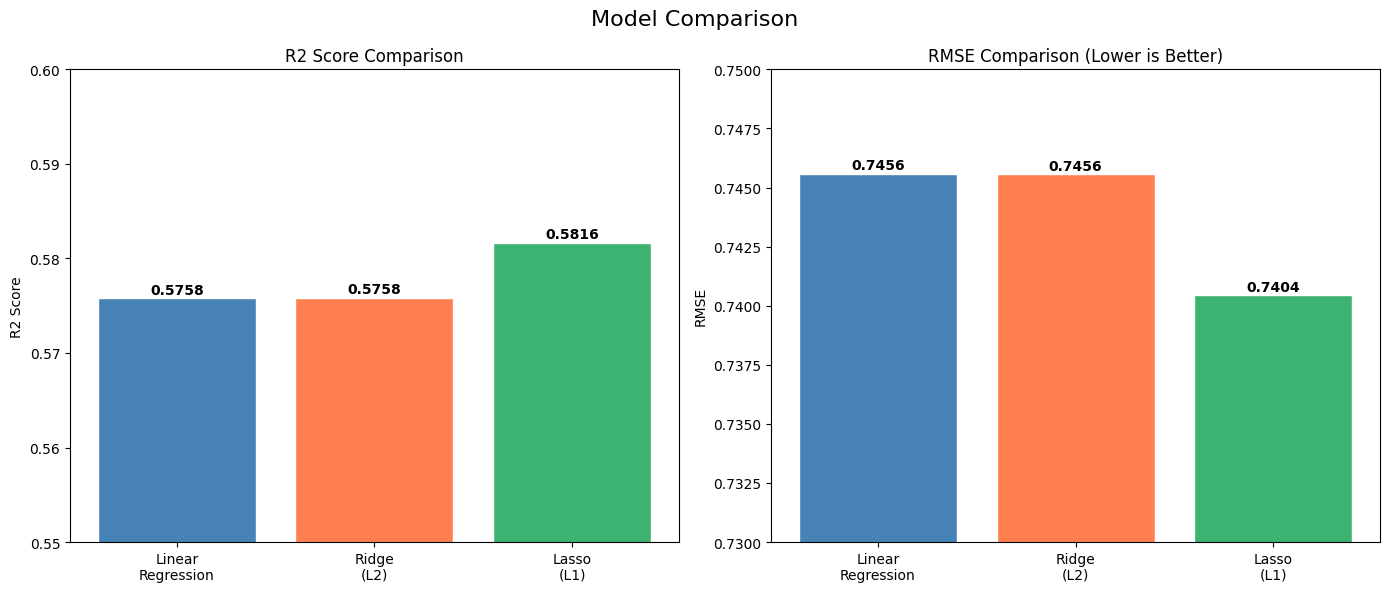

Model Comparison Graph Saved!


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=16)
models = ['Linear\nRegression', 'Ridge\n(L2)', 'Lasso\n(L1)']
r2_scores = [r2_lr, r2_ridge, r2_lasso]
colors = ['steelblue', 'coral', 'mediumseagreen']
axes[0].bar(models, r2_scores, color=colors, edgecolor='white')
axes[0].set_title('R2 Score Comparison')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0.55, 0.60)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', 
                 ha='center', fontweight='bold')
rmse_scores = [rmse_lr, rmse_ridge, rmse_lasso]
axes[1].bar(models, rmse_scores, color=colors, edgecolor='white')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(0.73, 0.75)
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.0002, f'{v:.4f}', 
                 ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/07_Regularization/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Model Comparison Graph Saved!")